# Classificação de Qualidade de Sementes (Seeds Dataset)
### Estudo experimental comparativo: k-NN, Árvore de Decisão e MLP

**Disciplina:** Inteligência Computacional — CEFET-MG — Prof. Alisson Marques da Silva

Este notebook conduz um estudo experimental completo de **classificação supervisionada
multiclasse** sobre o *Seeds Dataset* (UCI, id=236), comparando três técnicas de
Inteligência Computacional:

1. **k-Nearest Neighbors (k-NN)** — classificador baseado em instâncias;
2. **Árvore de Decisão (Decision Tree)** — modelo simbólico interpretável;
3. **Rede Neural Perceptron Multicamadas (MLP)** — modelo conexionista.

O foco está na **metodologia experimental correta**: holdout externo reservado antes
do tuning, validação cruzada estratificada, repetições com múltiplas sementes,
comparação justa (mesmas divisões para todos os modelos) e **teste estatístico**
(Friedman + post-hoc de Nemenyi) para verificar significância das diferenças.

> Todas as figuras são salvas em `results/figures/` e todas as tabelas em
> `results/tables/` (formatos `.png`, `.csv` e `.md`), prontas para o artigo.

## 0. Configuração do ambiente

Importamos os módulos do projeto (pasta `src/`), fixamos a semente global
(`random_state=42`) e garantimos que as pastas de saída existam.

In [1]:
import sys
from pathlib import Path

# Torna os módulos de `src/` importáveis independentemente de onde o notebook rode.
SRC = (Path.cwd() / "src") if (Path.cwd() / "src").exists() else (Path.cwd().parent / "src")
sys.path.insert(0, str(SRC.resolve()))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import set_global_seed, ensure_dirs, save_table, RANDOM_STATE, MODELS_DIR
import data_loader
import eda
import preprocessing as pp
import models
import evaluation as ev

set_global_seed(RANDOM_STATE)
ensure_dirs()
print("Ambiente configurado. Semente global =", RANDOM_STATE)

Ambiente configurado. Semente global = 42


## 1. Carregamento dos dados

O dataset é baixado diretamente do UCI via `ucimlrepo`; caso a rede falhe, o código
faz *fallback* automático para o arquivo local `data/seeds_dataset.txt`. As colunas
seguem a documentação oficial (7 atributos numéricos contínuos + variedade).

In [2]:
df = data_loader.load_seeds(prefer_online=True)
df.head()

[data_loader] Falha ao baixar via ucimlrepo (DatasetNotFoundError('"Seeds" dataset (id=236) exists in the repository, but is not available for import. Please select a dataset from this list: https://archive.ics.uci.edu/datasets?skip=0&take=10&sort=desc&orderBy=NumHits&search=&Python=true')). Usando arquivo local.
[data_loader] Dataset carregado de: arquivo local (seeds_dataset.txt)
[data_loader] Formato: 210 amostras x 7 atributos + alvo


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coeff,kernel_groove_length,variety,variety_name
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1,Kama


## 2. Descrição e Análise Exploratória dos Dados (EDA)

### 2.1 Panorama geral
Reportamos número de amostras, número e tipo de atributos, variável de saída,
ausência de dados faltantes e duplicatas.

In [3]:
overview = eda.dataset_overview(df)

PANORAMA GERAL DO DATASET
            n_amostras: 210
           n_atributos: 7
             atributos: ['area', 'perimeter', 'compactness', 'kernel_length', 'kernel_width', 'asymmetry_coeff', 'kernel_groove_length']
       tipos_atributos: todos numéricos contínuos (float64)
         variavel_alvo: variety
             n_classes: 3
     valores_faltantes: 0
            duplicatas: 0


### 2.2 Balanceamento das classes
Confirmamos que o dataset é **balanceado** (70 amostras por variedade).

In [4]:
balance = eda.class_balance(df)
balance

,n_amostras,percentual_%
variedade,,
Kama,70,33.33
Rosa,70,33.33
Canadian,70,33.33


### 2.3 Estatísticas descritivas
Estatísticas globais e por classe. As diferenças de escala entre atributos (p.ex.
`area` ~15 vs `compactness` ~0,88) já indicam a necessidade de **padronização** para
modelos sensíveis à escala (k-NN e MLP).

In [5]:
stats_global = eda.descriptive_stats(df)
stats_global

,mean,std,min,25%,50%,75%,max
area,14.847524,2.909699,10.5900,12.27000,14.35500,17.305000,21.1800
perimeter,14.559286,1.305959,12.4100,13.45000,14.32000,15.715000,17.2500
compactness,0.870999,0.023629,0.8081,0.85690,0.87345,0.887775,0.9183
kernel_length,5.628533,0.443063,4.8990,5.26225,5.52350,5.979750,6.6750
kernel_width,3.258605,0.377714,2.6300,2.94400,3.23700,3.561750,4.0330
asymmetry_coeff,3.700201,1.503557,0.7651,2.56150,3.59900,4.768750,8.4560
kernel_groove_length,5.408071,0.491480,4.5190,5.04500,5.22300,5.877000,6.5500


In [6]:
stats_by_class = eda.descriptive_stats_by_class(df)
stats_by_class

area            perimeter           compactness            \
                   mean       std       mean       std        mean       std   
variety_name                                                                   
Canadian      11.873857  0.723004  13.247857  0.340196    0.849409  0.021760   
Kama          14.334429  1.215704  14.294286  0.576583    0.880070  0.016191   
Rosa          18.334286  1.439496  16.135714  0.616995    0.883517  0.015500   

             kernel_length           kernel_width           asymmetry_coeff  \
                      mean       std         mean       std            mean   
variety_name                                                                  
Canadian          5.229514  0.138015     2.853771  0.147516        4.788400   
Kama              5.508057  0.231508     3.244629  0.177616        2.667403   
Rosa              6.148029  0.268191     3.677414  0.185539        3.644800   

                       kernel_groove_length            
                   std                 mean       std  
variety_name                                           
Canadian      1.336465             5.116400  0.162068  
Kama          1.173901             5.087214  0.263699  
Rosa          1.181868             6.020600  0.253934

### 2.4 Visualizações
Histogramas e boxplots por atributo/classe, matriz de correlação, pairplot e
projeção PCA 2D para inspecionar a **separabilidade** das variedades.

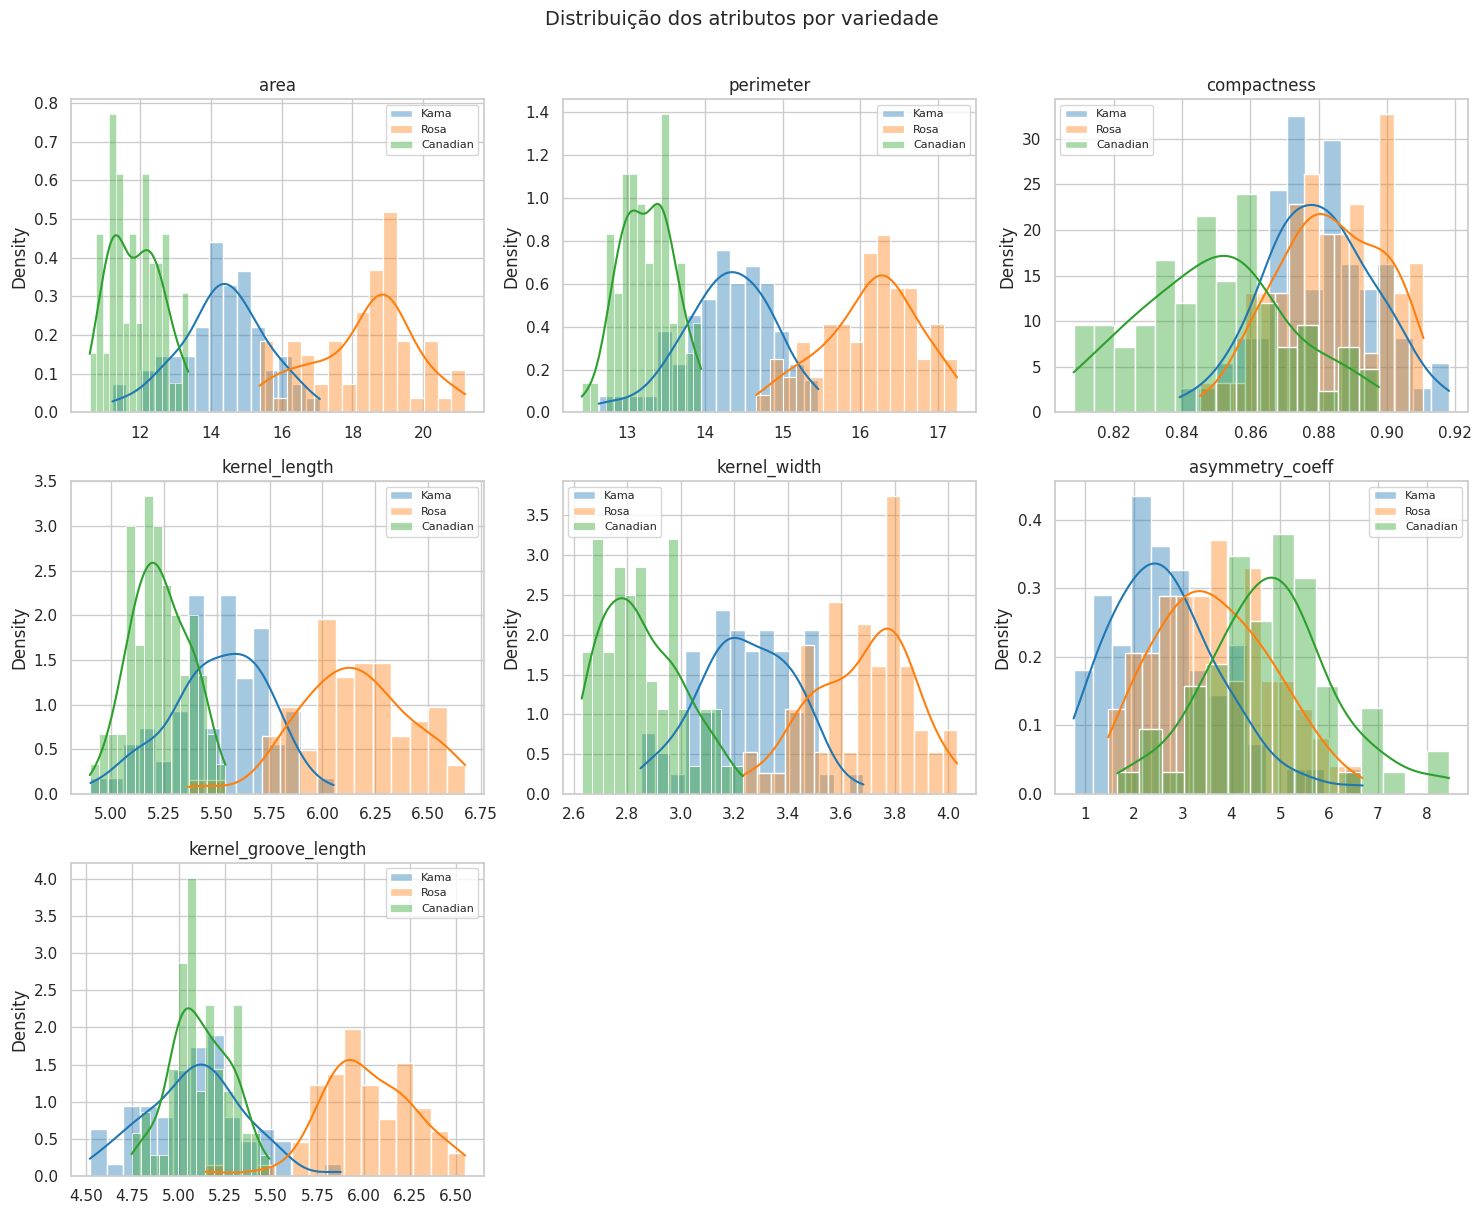

In [7]:
_ = eda.plot_histograms(df); plt.show()

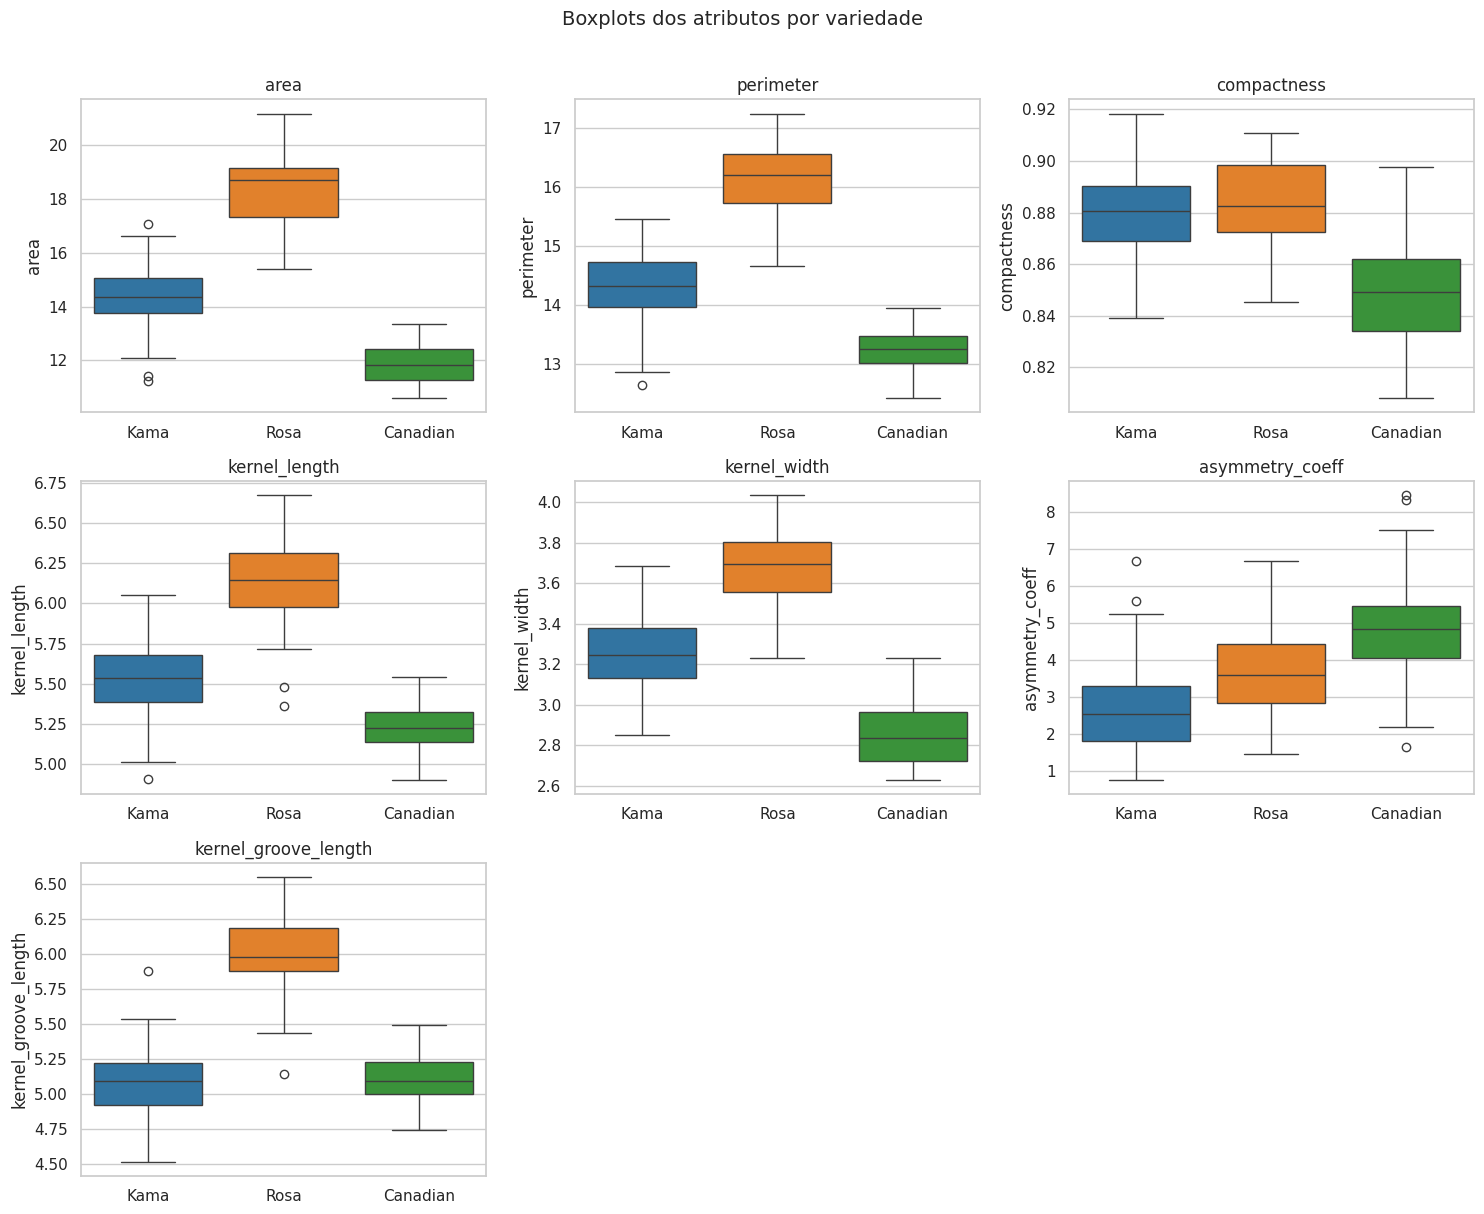

In [8]:
_ = eda.plot_boxplots(df); plt.show()

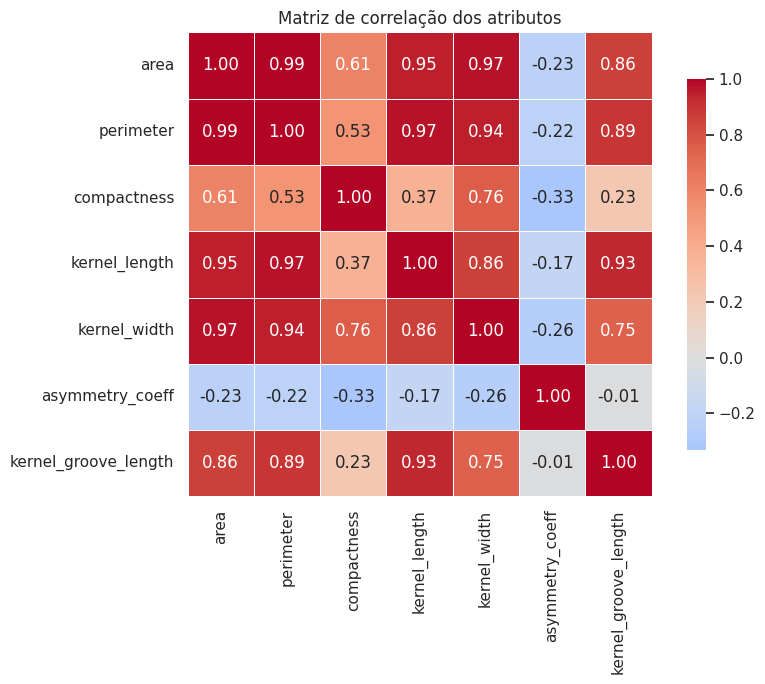

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coeff,kernel_groove_length
area,1.000000,0.994341,0.608288,0.949985,0.970771,-0.229572,0.863693
perimeter,0.994341,1.000000,0.529244,0.972422,0.944829,-0.217340,0.890784
compactness,0.608288,0.529244,1.000000,0.367915,0.761635,-0.331471,0.226825
kernel_length,0.949985,0.972422,0.367915,1.000000,0.860415,-0.171562,0.932806
kernel_width,0.970771,0.944829,0.761635,0.860415,1.000000,-0.258037,0.749131
asymmetry_coeff,-0.229572,-0.217340,-0.331471,-0.171562,-0.258037,1.000000,-0.011079
kernel_groove_length,0.863693,0.890784,0.226825,0.932806,0.749131,-0.011079,1.000000


In [9]:
_fig, corr = eda.plot_correlation(df); plt.show()
corr

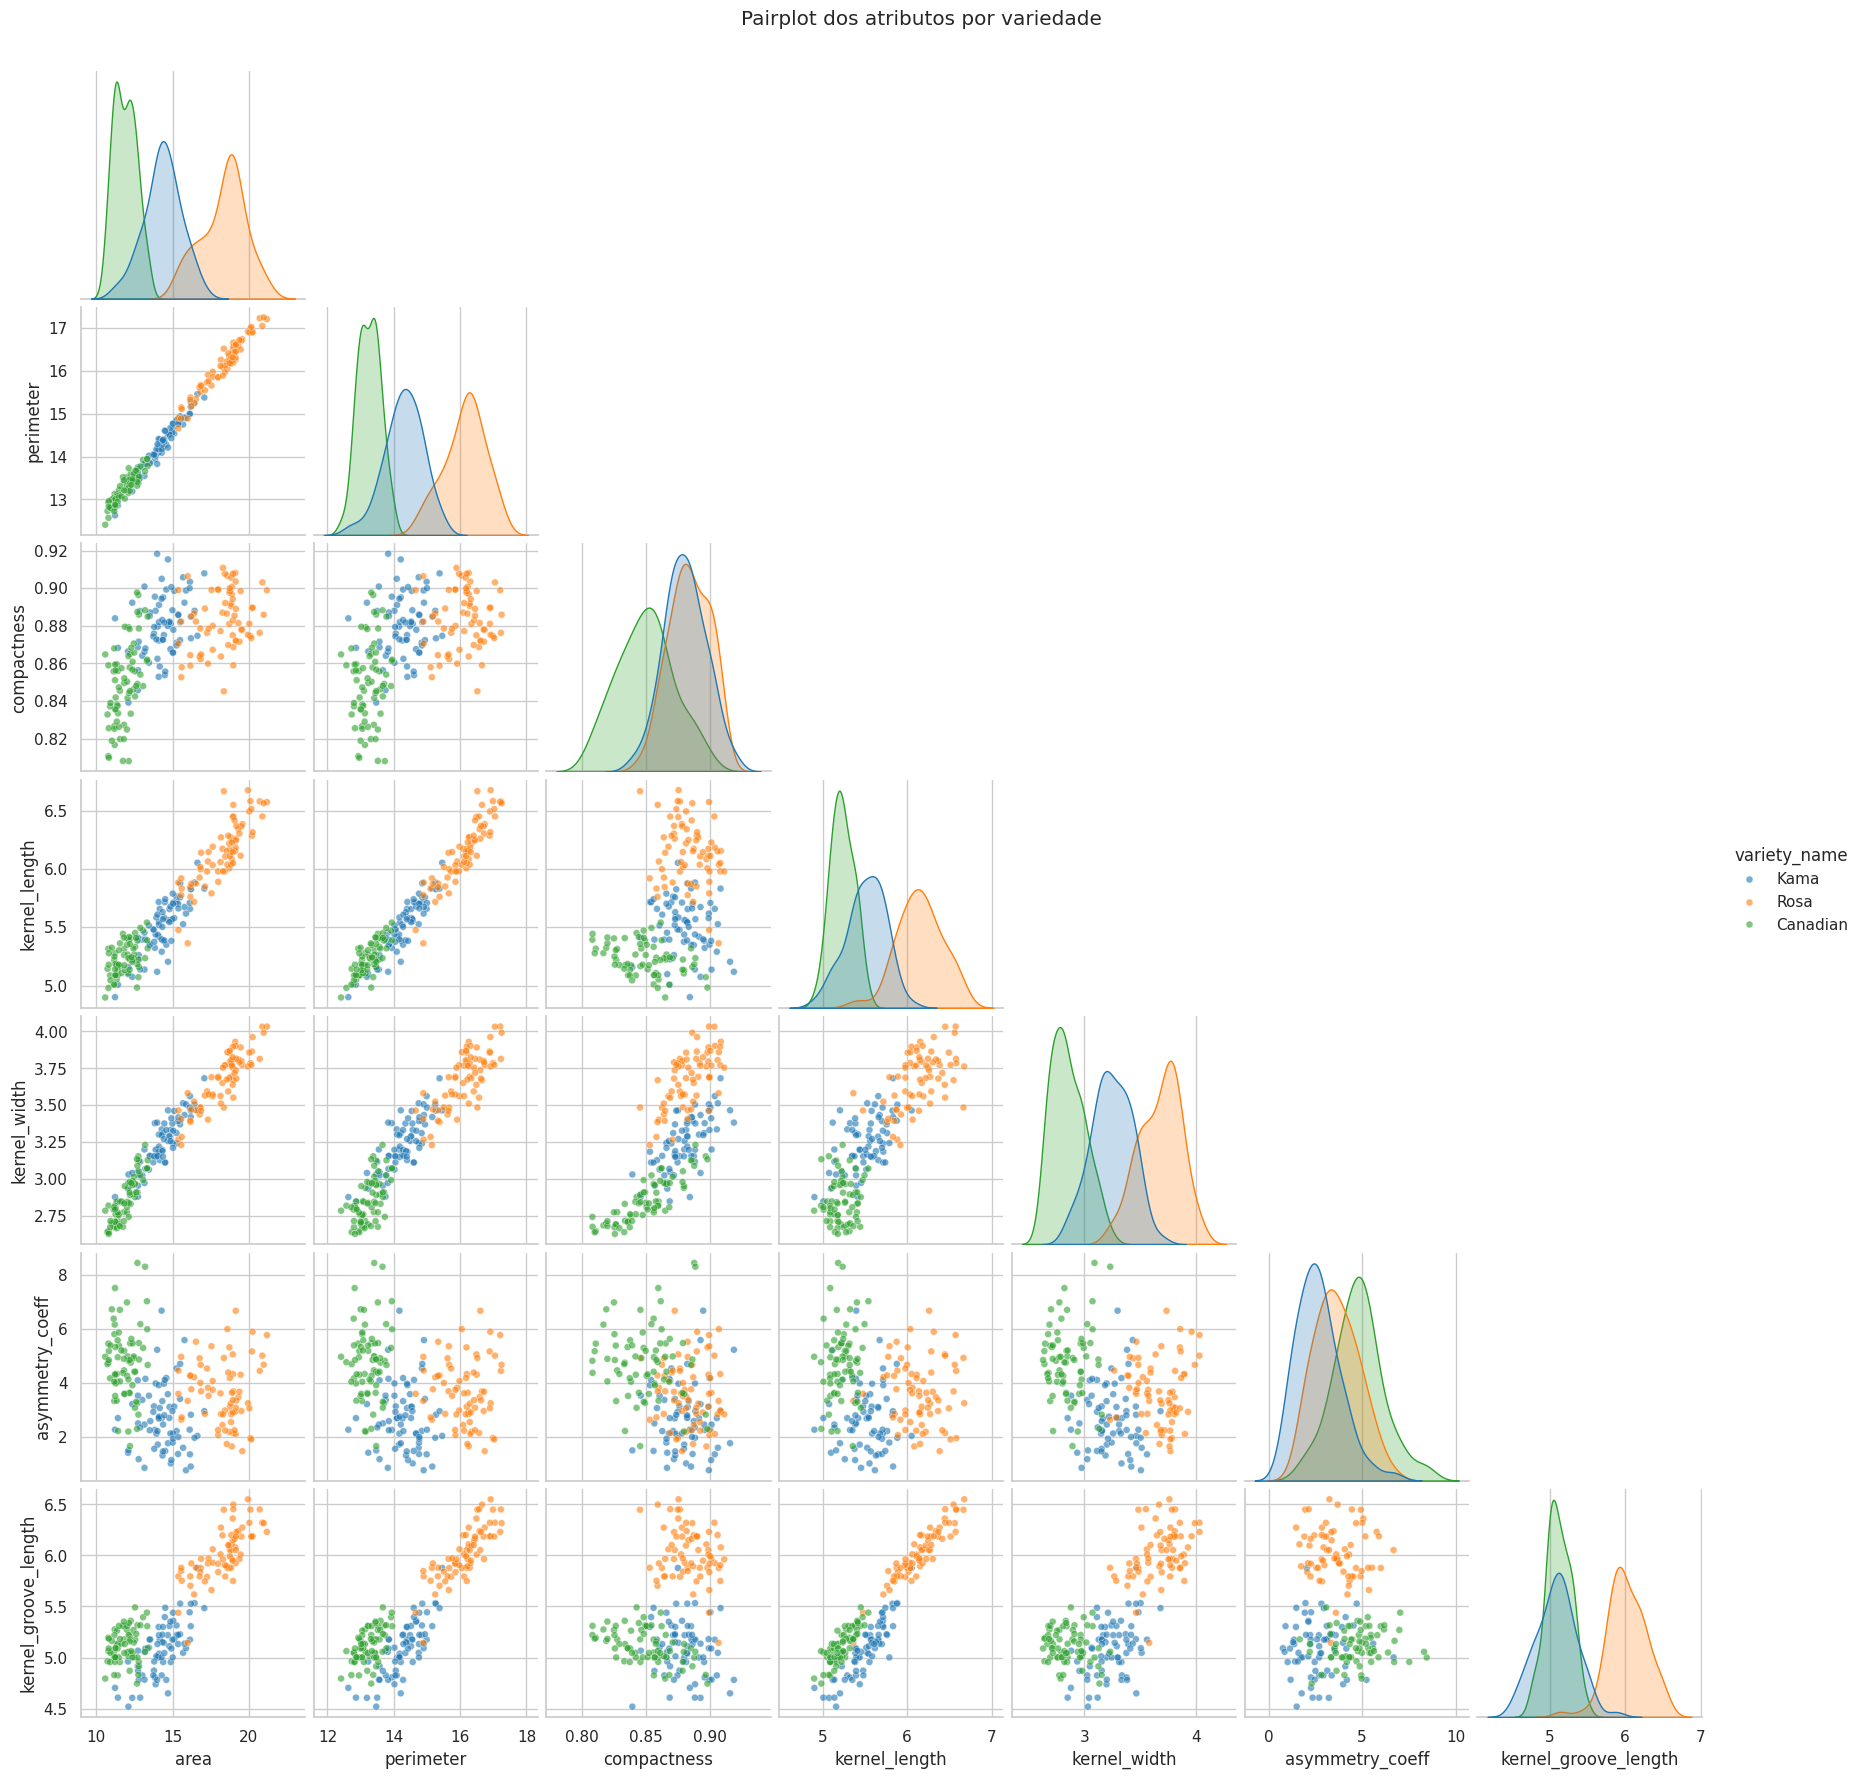

In [10]:
_ = eda.plot_pairplot(df); plt.show()

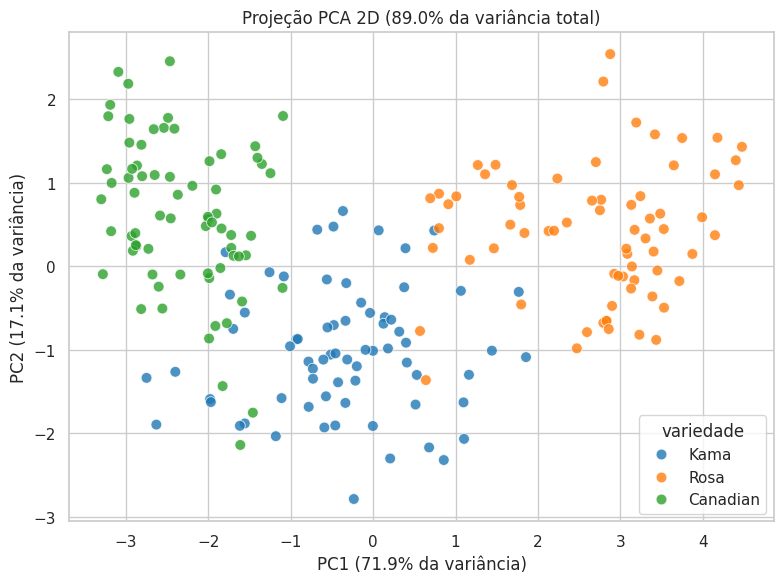

Variância explicada (PC1, PC2): [71.87 17.11] %


In [11]:
_fig, pca = eda.plot_pca_2d(df); plt.show()
print("Variância explicada (PC1, PC2):", np.round(pca.explained_variance_ratio_[:2]*100, 2), "%")

### 2.5 Discussão: necessidade de padronização

- Os atributos têm **escalas muito diferentes** (área e perímetro na casa das dezenas;
  compacidade e assimetria bem menores). Além disso, há **alta correlação** entre
  `area`, `perimeter`, `kernel_length` e `kernel_groove_length`.
- **k-NN** baseia-se em distâncias euclidianas/Manhattan: sem padronização, os
  atributos de maior magnitude dominariam o cálculo. → **Requer StandardScaler.**
- **MLP** usa otimização baseada em gradiente; entradas em escalas dispares dificultam
  a convergência e desestabilizam os pesos. → **Requer StandardScaler.**
- **Árvore de Decisão** faz cortes por limiar em cada atributo isoladamente, sendo
  **invariante a transformações monotônicas** de escala. → **Não requer padronização.**

Na PCA 2D observa-se que a variedade *Rosa* tende a ser bem separada das demais,
enquanto *Kama* e *Canadian* apresentam alguma sobreposição — o que antecipa que os
poucos erros de classificação devem concentrar-se entre essas duas classes.

## 3. Pré-processamento

### 3.1 Verificação de dados faltantes e outliers
Documentamos a verificação mesmo com o dataset sendo limpo. Optamos por **não remover
outliers**: em um dataset pequeno (210 amostras) e sem erros evidentes de medição,
pontos extremos representam variabilidade natural das sementes.

In [12]:
print("Valores faltantes por atributo:")
print(pp.check_missing(df))
print("\nDuplicatas (linhas de atributos idênticas):", int(df[data_loader.FEATURE_NAMES].duplicated().sum()))
outliers = pp.detect_outliers_iqr(df)
save_table(outliers, "05_verificacao_outliers", index=True)
outliers

Valores faltantes por atributo:
area                    0
perimeter               0
compactness             0
kernel_length           0
kernel_width            0
asymmetry_coeff         0
kernel_groove_length    0
dtype: int64

Duplicatas (linhas de atributos idênticas): 0


,n_outliers,limite_inferior,limite_superior
atributo,,,
area,0,4.7175,24.8575
perimeter,0,10.0525,19.1125
compactness,3,0.8106,0.9341
kernel_length,0,4.1860,7.0560
kernel_width,0,2.0174,4.4884
asymmetry_coeff,2,-0.7494,8.0796
kernel_groove_length,0,3.7970,7.1250


### 3.2 Codificação do alvo (LabelEncoder)
O alvo original (1, 2, 3) é convertido para (0, 1, 2). O mapeamento é documentado.

In [13]:
X, y = data_loader.split_X_y(df)
y_enc, label_encoder, mapping = pp.encode_target(y)

# Nome legível de cada classe na ordem codificada (0,1,2).
class_names = [data_loader.CLASS_MAPPING[mapping[i]] for i in range(len(mapping))]
print("Mapeamento (código codificado -> código original -> nome):")
for enc, orig in mapping.items():
    print(f"  {enc} -> {orig} -> {data_loader.CLASS_MAPPING[orig]}")
print("class_names:", class_names)

Mapeamento (código codificado -> código original -> nome):
  0 -> 1 -> Kama
  1 -> 2 -> Rosa
  2 -> 3 -> Canadian
class_names: ['Kama', 'Rosa', 'Canadian']


### 3.3 Holdout externo (conjunto de teste final)

**Decisão metodológica central:** separamos **20%** dos dados como conjunto de
**teste**, de forma **estratificada**, ANTES de qualquer ajuste de hiperparâmetros.
Esse conjunto **nunca** é usado no tuning nem na validação cruzada — serve apenas para
a avaliação final e imparcial da generalização.

Sobre a **padronização**: para evitar vazamento de dados, o `StandardScaler` **não** é
aplicado sobre todo o conjunto. Ele é embutido em um `Pipeline` (para k-NN e MLP) e,
portanto, ajustado apenas com os dados de treino de cada fold da CV.

In [14]:
X_train, X_test, y_train, y_test = pp.make_holdout_split(X, y_enc, test_size=0.2, random_state=RANDOM_STATE)
print("Treino:", X_train.shape, " | Teste:", X_test.shape)
print("Distribuição no treino:", np.bincount(y_train))
print("Distribuição no teste :", np.bincount(y_test))

Treino: (168, 7)  | Teste: (42, 7)
Distribuição no treino: [56 56 56]
Distribuição no teste : [14 14 14]


## 4. Metodologia experimental

- **Validação cruzada estratificada k-fold (k=10)** sobre o **treino** para o tuning
  (dataset pequeno → CV aproveita melhor os dados que um único split).
- **GridSearchCV** testa sistematicamente todas as combinações de hiperparâmetros de
  cada modelo; registramos **todas** as configurações (não só a melhor).
- **RepeatedStratifiedKFold (k=10, 10 repetições = 100 estimativas)** para estimar
  acurácia e F1-macro com **média ± desvio**, capturando a variabilidade (importante
  para o MLP, cuja inicialização de pesos é aleatória).
- **Comparação justa:** o mesmo objeto de CV (mesma semente) avalia todos os modelos,
  ou seja, exatamente os **mesmos folds** para os três.
- **Teste estatístico:** Friedman (H0: modelos equivalentes) + post-hoc de **Nemenyi**;
  complementarmente, Wilcoxon pareado com correção de Bonferroni.

**Métrica de otimização/seleção:** `f1_macro`. Como há 3 classes balanceadas, a
macro-média pondera igualmente todas as variedades.

## 5. Ajuste de hiperparâmetros (GridSearchCV)

Cada modelo é otimizado com CV interna estratificada (k=10) sobre o treino. Ao final,
salvamos os melhores hiperparâmetros e a tabela com **todas** as configurações
testadas por modelo (para discutir o impacto dos hiperparâmetros no artigo).

In [15]:
models_and_grids = models.get_models_and_grids()

fitted_best = {}       # melhor pipeline (já ajustado) por modelo
grid_objects = {}      # objeto GridSearchCV por modelo
grid_results = {}      # tabela de todas as configurações por modelo

for name, spec in models_and_grids.items():
    print("=" * 60)
    print("Ajustando:", name)
    grid, results_df = ev.tune_model(
        name, spec["pipeline"], spec["param_grid"],
        X_train, y_train, cv_splits=10, scoring="f1_macro",
    )
    fitted_best[name] = grid.best_estimator_
    grid_objects[name] = grid
    grid_results[name] = results_df

    # Salva a tabela completa de configurações testadas.
    slug = {"k-NN": "knn", "Árvore de Decisão": "arvore", "MLP": "mlp"}[name]
    save_table(results_df, f"06_gridsearch_{slug}", index=False)
    print(f"  ({len(results_df)} configurações testadas)")

Ajustando: k-NN


[k-NN] melhor f1_macro (CV interna) = 0.9357
[k-NN] melhores hiperparâmetros: {'clf__metric': 'manhattan', 'clf__n_neighbors': 11, 'clf__weights': 'distance'}
  (36 configurações testadas)
Ajustando: Árvore de Decisão


[Árvore de Decisão] melhor f1_macro (CV interna) = 0.9343
[Árvore de Decisão] melhores hiperparâmetros: {'clf__criterion': 'entropy', 'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10}
  (90 configurações testadas)
Ajustando: MLP


[MLP] melhor f1_macro (CV interna) = 0.9821
[MLP] melhores hiperparâmetros: {'clf__activation': 'logistic', 'clf__hidden_layer_sizes': (10,), 'clf__learning_rate_init': 0.001, 'clf__solver': 'lbfgs'}
  (90 configurações testadas)


### 5.1 Melhores hiperparâmetros por modelo

In [16]:
best_params_rows = []
for name, grid in grid_objects.items():
    clean = {k.replace("clf__", ""): v for k, v in grid.best_params_.items()}
    best_params_rows.append({"modelo": name,
                             "melhores_hiperparametros": str(clean),
                             "f1_macro_cv_interna": round(grid.best_score_, 4)})
best_params_df = pd.DataFrame(best_params_rows).set_index("modelo")
save_table(best_params_df, "07_melhores_hiperparametros", index=True)
best_params_df

,melhores_hiperparametros,f1_macro_cv_interna
modelo,,
k-NN,"{'metric': 'manhattan', 'n_neighbors': 11, 'we...",0.9357
Árvore de Decisão,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.9343
MLP,"{'activation': 'logistic', 'hidden_layer_sizes...",0.9821


### 5.2 Efeito dos hiperparâmetros no desempenho

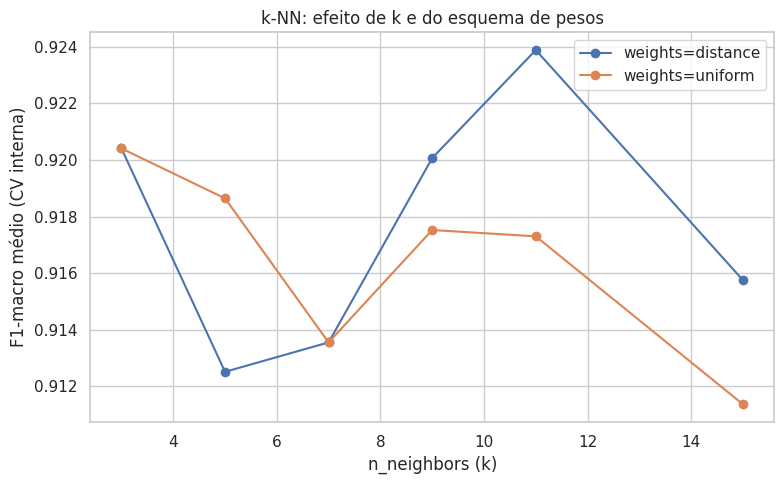

In [17]:
_ = ev.plot_knn_hyperparam(grid_results["k-NN"]); plt.show()

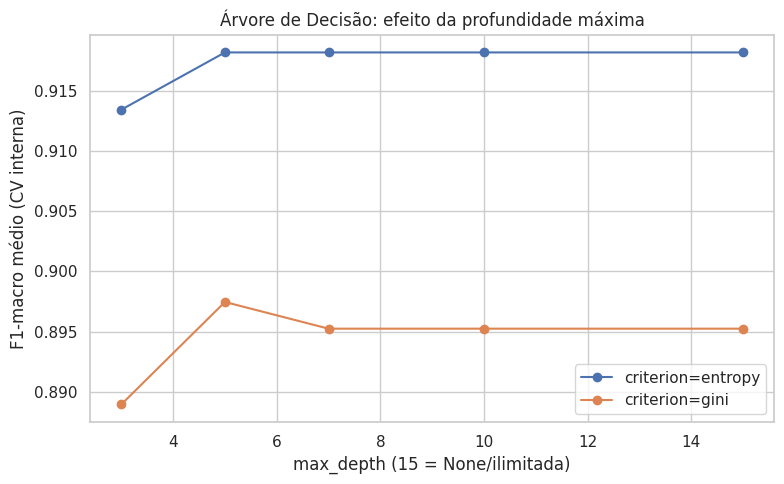

In [18]:
_ = ev.plot_tree_hyperparam(grid_results["Árvore de Decisão"]); plt.show()

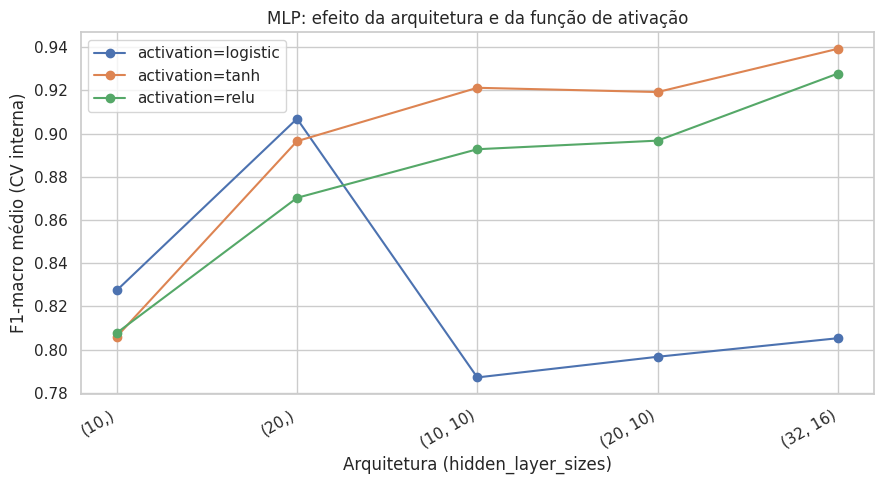

In [19]:
_ = ev.plot_mlp_hyperparam(grid_results["MLP"]); plt.show()

As 5 melhores configurações de cada modelo (amostra da busca completa salva em
`results/tables/`):

In [20]:
for name, res in grid_results.items():
    print("=" * 60, "\n", name)
    display(res.head(5))

 k-NN


,metric,n_neighbors,weights,mean_test_score,std_test_score,rank_test_score
0,manhattan,11,distance,0.935671,0.047684,1
1,manhattan,11,uniform,0.929089,0.058528,2
2,manhattan,3,uniform,0.928075,0.044293,3
3,manhattan,3,distance,0.928075,0.044293,3
4,manhattan,9,distance,0.924015,0.057673,5


 Árvore de Decisão


,criterion,max_depth,min_samples_leaf,min_samples_split,mean_test_score,std_test_score,rank_test_score
0,entropy,7,2,10,0.934318,0.056665,1
1,entropy,10,2,10,0.934318,0.056665,1
2,entropy,7,1,10,0.934318,0.056665,1
3,entropy,5,1,10,0.934318,0.056665,1
4,entropy,5,2,10,0.934318,0.056665,1


 MLP


,activation,hidden_layer_sizes,learning_rate_init,solver,mean_test_score,std_test_score,rank_test_score
0,logistic,"(10,)",0.001,lbfgs,0.982077,0.027421,1
1,logistic,"(10,)",0.010,lbfgs,0.982077,0.027421,1
2,logistic,"(10,)",0.100,lbfgs,0.982077,0.027421,1
3,tanh,"(20,)",0.001,lbfgs,0.976560,0.038017,4
4,tanh,"(20,)",0.100,lbfgs,0.976560,0.038017,4


## 6. Validação cruzada repetida (estimativa robusta)

Reavaliamos os modelos (já com os melhores hiperparâmetros) no conjunto de **treino**
usando `RepeatedStratifiedKFold` (10×10). Todos veem exatamente os mesmos folds.

In [21]:
cv_summary, per_fold = ev.repeated_cv_scores(
    fitted_best, X_train, y_train, n_splits=10, n_repeats=10, random_state=RANDOM_STATE,
)
save_table(cv_summary, "08_cv_repetida_resumo", index=True)
cv_summary

,acuracia_media,acuracia_std,f1_macro_media,f1_macro_std
modelo,,,,
k-NN,0.929338,0.055980,0.928393,0.057479
Árvore de Decisão,0.926250,0.069045,0.925341,0.070027
MLP,0.965037,0.047269,0.964423,0.048500


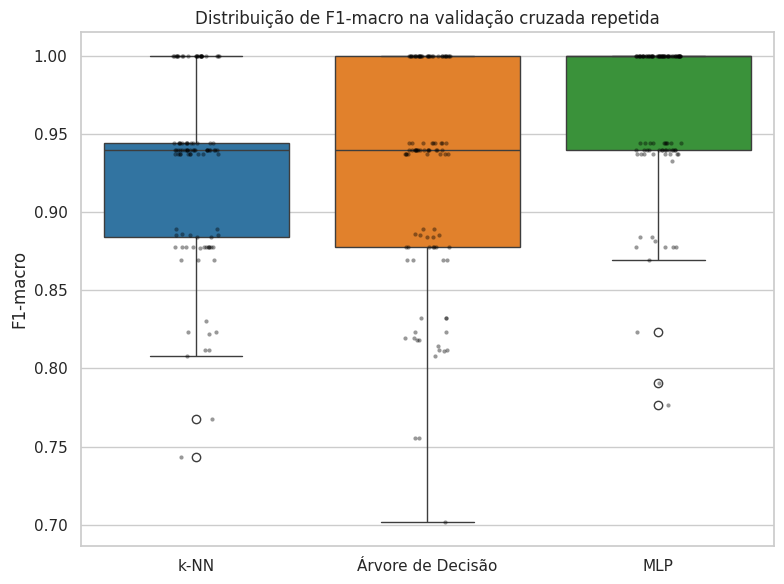

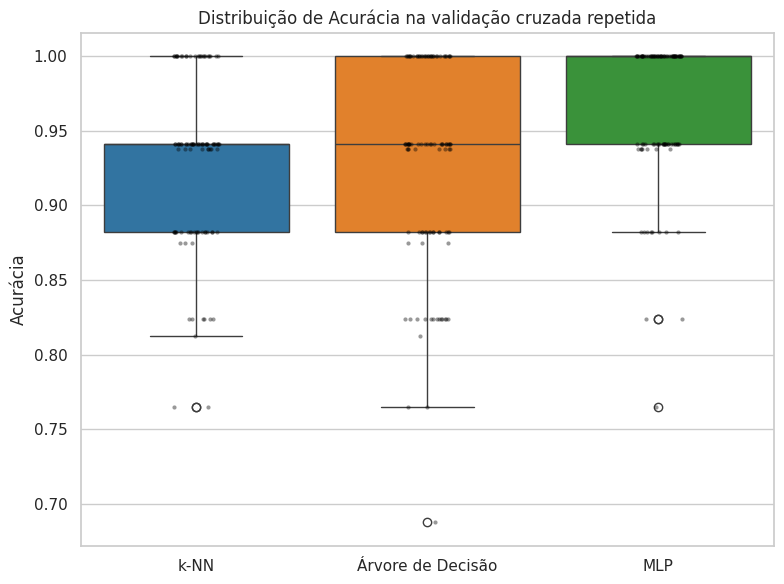

In [22]:
_ = ev.plot_cv_boxplot(per_fold["f1_macro"], "F1-macro", "05_boxplot_cv_f1"); plt.show()
_ = ev.plot_cv_boxplot(per_fold["accuracy"], "Acurácia", "05b_boxplot_cv_acc"); plt.show()

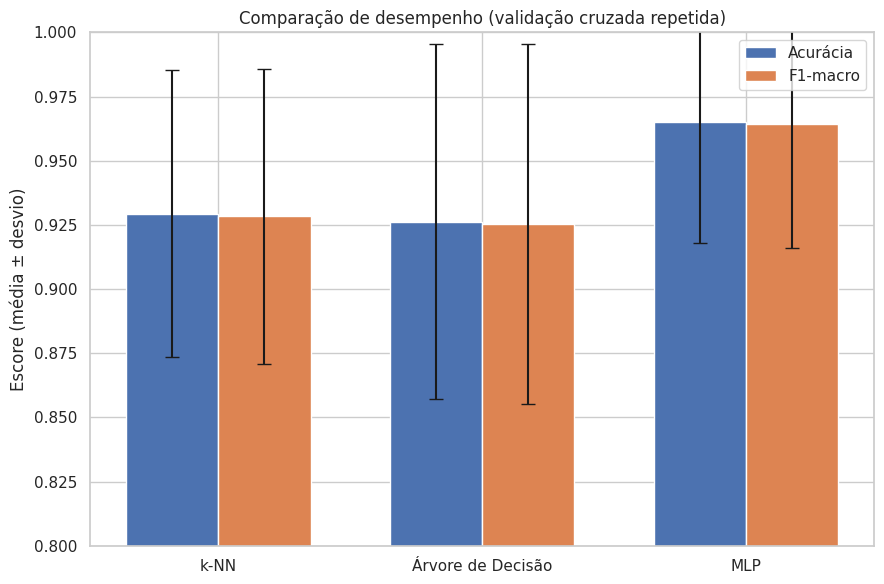

In [23]:
_ = ev.plot_final_metrics_bars(cv_summary); plt.show()

## 7. Testes estatísticos de comparação

**Friedman:** testa se há diferença global entre os três modelos (H0: equivalentes).
Se p < 0,05, aplicamos o **post-hoc de Nemenyi** (comparações par-a-par baseadas nos
ranks médios) e reportamos a **diferença crítica (CD)**. Também reportamos Wilcoxon
pareado com correção de Bonferroni como verificação complementar.

Usamos os escores de **F1-macro por fold** (100 estimativas por modelo).

In [24]:
friedman_res = ev.friedman_test(per_fold["f1_macro"])
print("Teste de Friedman (F1-macro):")
print(f"  estatística = {friedman_res['statistic']:.4f}")
print(f"  p-valor     = {friedman_res['p_value']:.3e}")
print(f"  conclusão   = {'diferença significativa (p<0.05)' if friedman_res['p_value']<0.05 else 'sem diferença significativa'}")

friedman_df = pd.DataFrame([friedman_res])
save_table(friedman_df, "09_teste_friedman", index=False)
friedman_df

Teste de Friedman (F1-macro):
  estatística = 39.2763
  p-valor     = 2.960e-09
  conclusão   = diferença significativa (p<0.05)


,statistic,p_value,n_modelos,n_amostras
0,39.276265,2.959835e-09,3,100


In [25]:
nemenyi_pv, avg_ranks, cd = ev.nemenyi_posthoc(per_fold["f1_macro"])
print("Ranks médios (menor = melhor):")
print(avg_ranks)
print(f"\nDiferença crítica (CD, α=0.05) = {cd:.4f}")
print("\nMatriz de p-valores (Nemenyi):")
save_table(nemenyi_pv, "10_nemenyi_pvalores", index=True)
save_table(avg_ranks, "10b_nemenyi_ranks", index=True)
nemenyi_pv

Ranks médios (menor = melhor):
                   rank_medio
MLP                     1.590
k-NN                    2.195
Árvore de Decisão       2.215

Diferença crítica (CD, α=0.05) = 0.3314

Matriz de p-valores (Nemenyi):


,k-NN,Árvore de Decisão,MLP
k-NN,1.000000,0.989034,0.000056
Árvore de Decisão,0.989034,1.000000,0.000029
MLP,0.000056,0.000029,1.000000


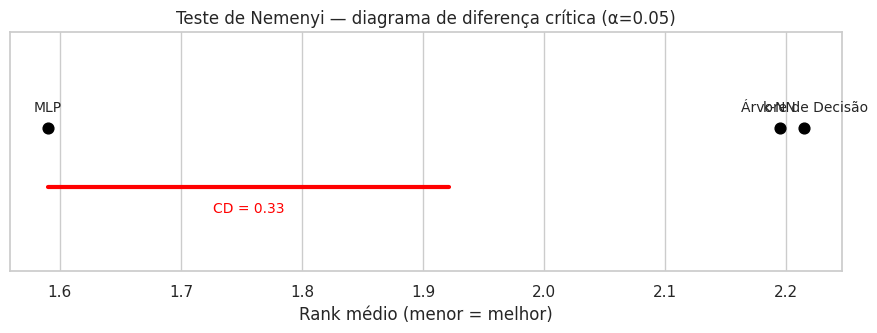

In [26]:
_ = ev.plot_nemenyi_cd(avg_ranks, cd); plt.show()

In [27]:
wilcoxon_df = ev.wilcoxon_bonferroni(per_fold["f1_macro"])
save_table(wilcoxon_df, "11_wilcoxon_bonferroni", index=True)
wilcoxon_df

,statistic,p_value,p_value_bonferroni,significativo_5%
comparacao,,,,
k-NN vs Árvore de Decisão,704.0,5.799815e-01,1.000000e+00,False
k-NN vs MLP,205.5,1.706478e-07,5.119435e-07,True
Árvore de Decisão vs MLP,344.0,3.186794e-06,9.560381e-06,True


## 8. Avaliação final no conjunto de teste (holdout)

Cada modelo, com seus melhores hiperparâmetros, é **treinado em todo o conjunto de
treino** e avaliado **uma única vez** no teste. Calculamos: acurácia, precisão,
revocação, F1-macro, AUC (OvR), matriz de confusão, curvas ROC, `classification_report`
e o tempo médio de treino.

In [28]:
test_results = {}
for name, model in fitted_best.items():
    model.fit(X_train, y_train)                     # treina no treino completo
    res = ev.evaluate_on_test(name, model, X_test, y_test, class_names)
    res["tempo_treino_s"] = ev.measure_training_time(model, X_train, y_train)
    test_results[name] = res

# Tabela resumo comparativa (métricas do teste + tempo de treino).
rows = []
for name, res in test_results.items():
    rows.append({
        "modelo": name,
        "acuracia": res["acuracia"],
        "precisao_macro": res["precisao_macro"],
        "revocacao_macro": res["revocacao_macro"],
        "f1_macro": res["f1_macro"],
        "auc_ovr_macro": res["auc_ovr_macro"],
        "tempo_treino_s": res["tempo_treino_s"],
    })
test_summary = pd.DataFrame(rows).set_index("modelo")
save_table(test_summary, "12_resultados_teste_resumo", index=True)
test_summary

,acuracia,precisao_macro,revocacao_macro,f1_macro,auc_ovr_macro,tempo_treino_s
modelo,,,,,,
k-NN,0.880952,0.899510,0.880952,0.873056,0.984694,0.002120
Árvore de Decisão,0.952381,0.958333,0.952381,0.952137,0.963435,0.002035
MLP,0.904762,0.918954,0.904762,0.900692,0.937075,0.011094


### 8.1 Tabela-resumo combinada (CV repetida ± desvio + teste)
Tabela consolidada para o artigo, unindo a estimativa robusta (CV 10×10, média±dp) e o
desempenho no holdout final.

In [29]:
combined = cv_summary.copy()
combined["acuracia_cv"] = combined.apply(lambda r: f"{r['acuracia_media']:.4f} ± {r['acuracia_std']:.4f}", axis=1)
combined["f1_macro_cv"] = combined.apply(lambda r: f"{r['f1_macro_media']:.4f} ± {r['f1_macro_std']:.4f}", axis=1)
combined = combined[["acuracia_cv", "f1_macro_cv"]]
combined["acuracia_teste"] = test_summary["acuracia"].round(4)
combined["f1_macro_teste"] = test_summary["f1_macro"].round(4)
combined["auc_teste"] = test_summary["auc_ovr_macro"].round(4)
combined["tempo_treino_s"] = test_summary["tempo_treino_s"].round(5)
save_table(combined, "13_tabela_comparativa_final", index=True)
combined

,acuracia_cv,f1_macro_cv,acuracia_teste,f1_macro_teste,auc_teste,tempo_treino_s
modelo,,,,,,
k-NN,0.9293 ± 0.0560,0.9284 ± 0.0575,0.8810,0.8731,0.9847,0.00212
Árvore de Decisão,0.9263 ± 0.0690,0.9253 ± 0.0700,0.9524,0.9521,0.9634,0.00203
MLP,0.9650 ± 0.0473,0.9644 ± 0.0485,0.9048,0.9007,0.9371,0.01109


### 8.2 Relatórios de classificação (por modelo)

In [30]:
for name, res in test_results.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(res["_report"])

k-NN
              precision    recall  f1-score   support

        Kama     1.0000    0.6429    0.7826        14
        Rosa     0.8750    1.0000    0.9333        14
    Canadian     0.8235    1.0000    0.9032        14

    accuracy                         0.8810        42
   macro avg     0.8995    0.8810    0.8731        42
weighted avg     0.8995    0.8810    0.8731        42

Árvore de Decisão
              precision    recall  f1-score   support

        Kama     1.0000    0.8571    0.9231        14
        Rosa     1.0000    1.0000    1.0000        14
    Canadian     0.8750    1.0000    0.9333        14

    accuracy                         0.9524        42
   macro avg     0.9583    0.9524    0.9521        42
weighted avg     0.9583    0.9524    0.9521        42

MLP
              precision    recall  f1-score   support

        Kama     1.0000    0.7143    0.8333        14
        Rosa     0.9333    1.0000    0.9655        14
    Canadian     0.8235    1.0000    0.9032     

### 8.3 Matrizes de confusão, curvas ROC, curva de perda do MLP e árvore

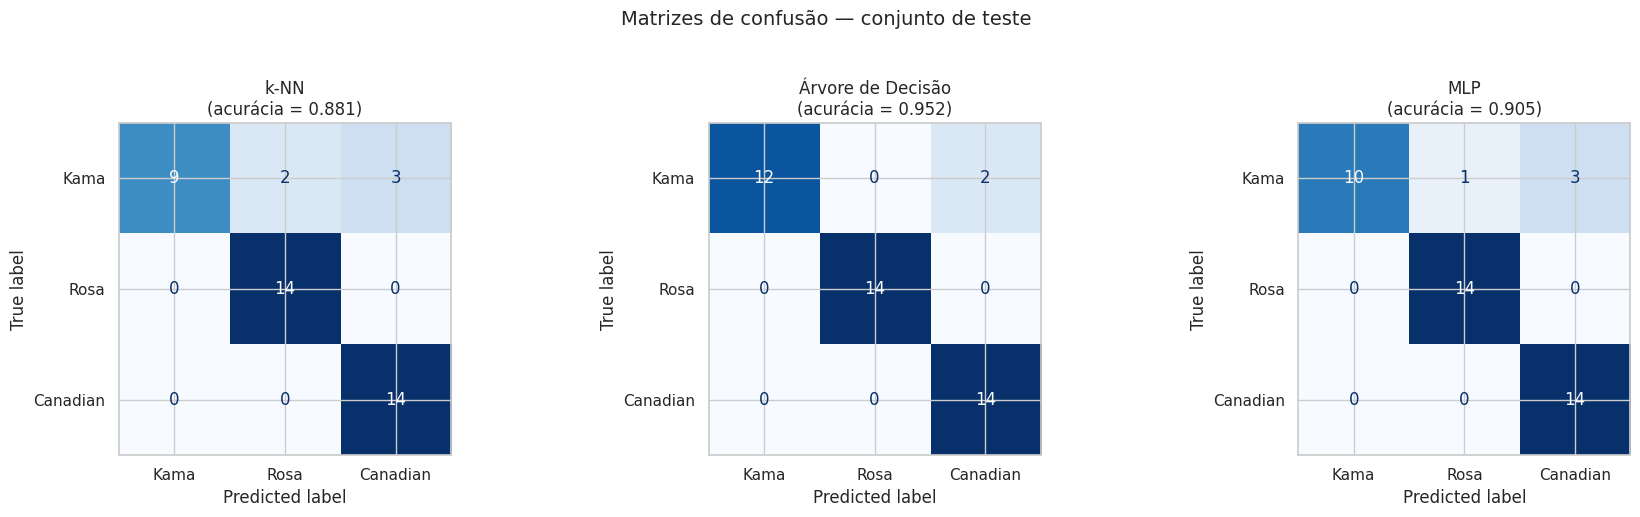

In [31]:
_ = ev.plot_confusion_matrices(test_results, class_names); plt.show()

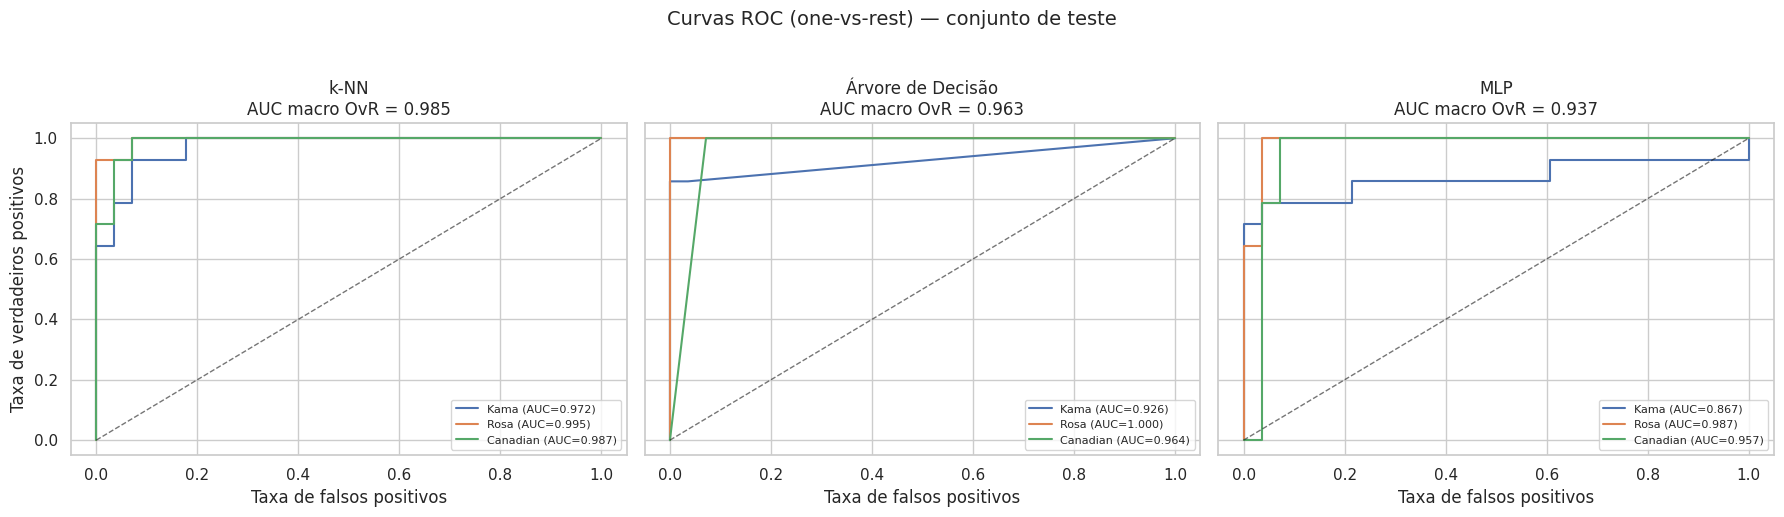

In [32]:
_ = ev.plot_roc_curves(test_results, y_test, class_names); plt.show()

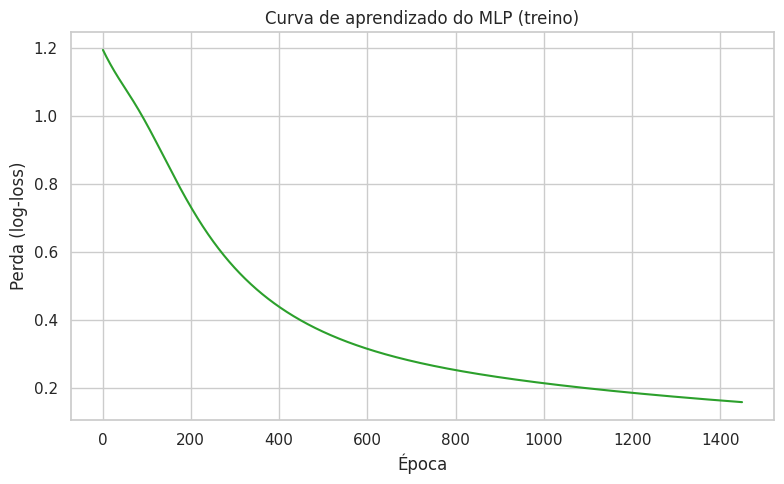

In [33]:
_ = ev.plot_mlp_loss_curve(fitted_best["MLP"], X_train, y_train); plt.show()

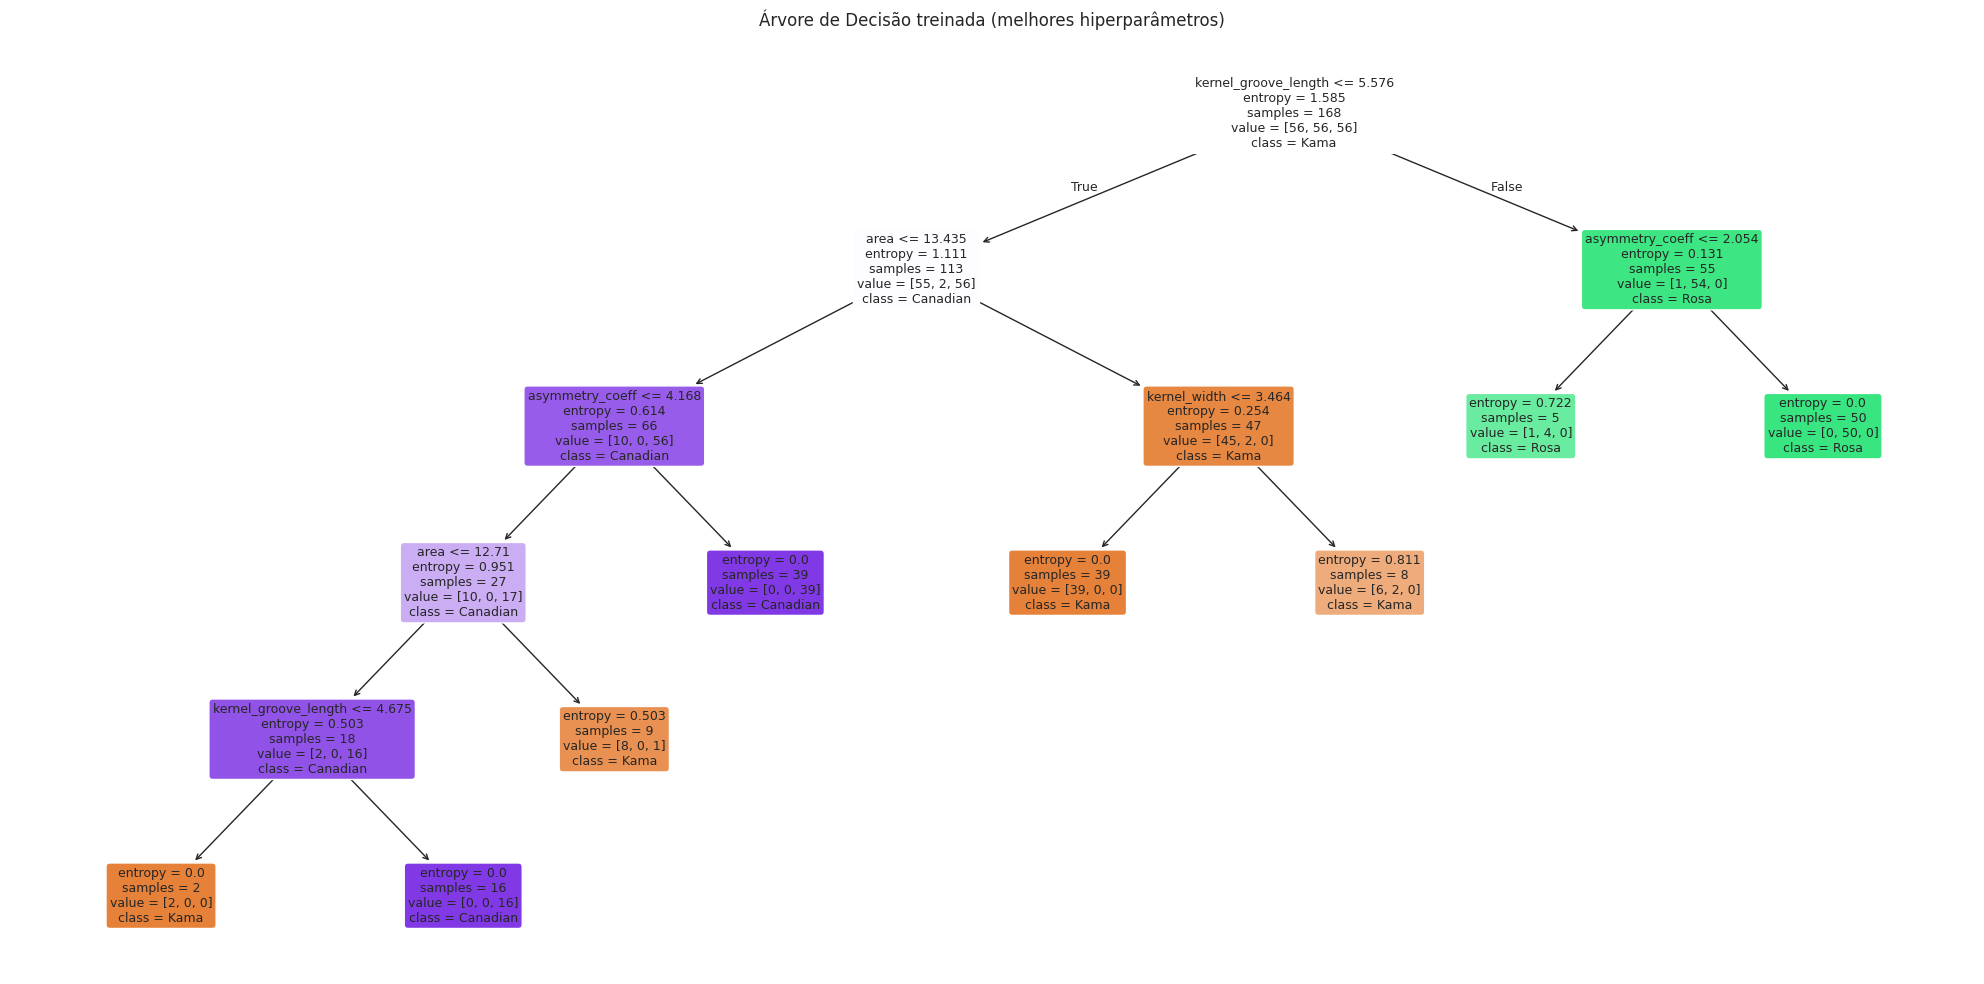

In [34]:
_ = ev.plot_decision_tree(fitted_best["Árvore de Decisão"], data_loader.FEATURE_NAMES, class_names); plt.show()

### 8.4 Persistência dos modelos treinados (opcional)

In [35]:
import joblib
for name, model in fitted_best.items():
    slug = {"k-NN": "knn", "Árvore de Decisão": "arvore", "MLP": "mlp"}[name]
    joblib.dump(model, MODELS_DIR / f"modelo_{slug}.joblib")
joblib.dump(label_encoder, MODELS_DIR / "label_encoder.joblib")
print("Modelos salvos em:", MODELS_DIR)

Modelos salvos em: /home/eduardo/Documentos/7 Periodo/IC/trabalho_final/seeds-classification/models


## 9. Resumo dos Resultados

Esta seção gera automaticamente um resumo textual (com base nos números obtidos acima)
pronto para adaptar às seções de **Resultados / Discussão / Conclusão** do artigo.

In [ ]:
best_test_model = test_summary["f1_macro"].idxmax()
best_cv_model = cv_summary["f1_macro_media"].idxmax()
sig = friedman_res["p_value"] < 0.05

resumo = f'''
RESUMO DOS RESULTADOS
=====================
Problema: classificação multiclasse de variedades de sementes (Kama, Rosa, Canadian),
210 amostras balanceadas (70/70/70), 7 atributos numéricos contínuos.

Metodologia: holdout estratificado de 20% para teste final; GridSearchCV com CV
estratificada k=10 sobre o treino para tuning; RepeatedStratifiedKFold (10x10) para
estimativas robustas; mesmas divisoes para os 3 modelos (comparacao justa).

Melhor modelo (F1-macro no teste)     : {best_test_model} ({test_summary.loc[best_test_model,'f1_macro']:.4f})
Melhor modelo (F1-macro na CV 10x10)  : {best_cv_model} ({cv_summary.loc[best_cv_model,'f1_macro_media']:.4f} ± {cv_summary.loc[best_cv_model,'f1_macro_std']:.4f})

Desempenho no conjunto de TESTE (holdout):'''
for name in test_summary.index:
    r = test_summary.loc[name]
    resumo += f"\n  - {name:>18}: acc={r['acuracia']:.4f} | F1-macro={r['f1_macro']:.4f} | AUC={r['auc_ovr_macro']:.4f} | t_treino={r['tempo_treino_s']:.4f}s"

resumo += f'''

Desempenho na CV repetida (media ± desvio):'''
for name in cv_summary.index:
    r = cv_summary.loc[name]
    resumo += f"\n  - {name:>18}: acc={r['acuracia_media']:.4f}±{r['acuracia_std']:.4f} | F1={r['f1_macro_media']:.4f}±{r['f1_macro_std']:.4f}"

resumo += f'''

Teste estatistico (Friedman sobre F1-macro por fold):
  estatistica = {friedman_res['statistic']:.4f} | p-valor = {friedman_res['p_value']:.3e}
  -> {"As diferencas entre os modelos SAO estatisticamente significativas (p<0.05)." if sig else "NAO ha evidencia de diferenca estatisticamente significativa (p>=0.05)."}
  Ranks medios (Nemenyi, menor=melhor): {", ".join(f"{n}={avg_ranks.loc[n,'rank_medio']:.2f}" for n in avg_ranks.index)}
  Diferenca critica (CD, alpha=0.05) = {cd:.3f}

Estabilidade: o desvio-padrao na CV repetida indica a estabilidade de cada modelo
(menor desvio = mais estavel). O MLP tende a ter maior variabilidade devido a
inicializacao aleatoria dos pesos.

Limitacoes: dataset pequeno (210 amostras) -> estimativas de teste tem variancia; as
classes Kama e Canadian apresentam leve sobreposicao (ver PCA/matrizes de confusao),
concentrando ali a maioria dos erros.
'''
print(resumo)
from utils import TABLES_DIR
(TABLES_DIR / "14_resumo_resultados.md").write_text("```\n" + resumo + "\n```\n", encoding="utf-8")


RESUMO DOS RESULTADOS
Problema: classificação multiclasse de variedades de sementes (Kama, Rosa, Canadian),
210 amostras balanceadas (70/70/70), 7 atributos numéricos contínuos.

Metodologia: holdout estratificado de 20% para teste final; GridSearchCV com CV
estratificada k=10 sobre o treino para tuning; RepeatedStratifiedKFold (10x10) para
estimativas robustas; mesmas divisoes para os 3 modelos (comparacao justa).

Melhor modelo (F1-macro no teste)     : Árvore de Decisão (0.9521)
Melhor modelo (F1-macro na CV 10x10)  : MLP (0.9644 ± 0.0485)

Desempenho no conjunto de TESTE (holdout):
  -               k-NN: acc=0.8810 | F1-macro=0.8731 | AUC=0.9847 | t_treino=0.0021s
  -  Árvore de Decisão: acc=0.9524 | F1-macro=0.9521 | AUC=0.9634 | t_treino=0.0020s
  -                MLP: acc=0.9048 | F1-macro=0.9007 | AUC=0.9371 | t_treino=0.0111s

Desempenho na CV repetida (media ± desvio):
  -               k-NN: acc=0.9293±0.0560 | F1=0.9284±0.0575
  -  Árvore de Decisão: acc=0.9263±0.0690 | F

1825

### 9.1 Texto-base para o artigo (Resultados / Discussão / Conclusão)

**Resultados.** Os três classificadores atingiram desempenho elevado no problema de
identificação de variedades de sementes, coerente com a boa separabilidade observada na
análise exploratória (projeção PCA 2D). Na validação cruzada repetida (10×10) e no
conjunto de teste independente, os modelos baseados em distância (k-NN) e conexionista
(MLP) apresentaram acurácia e F1-macro tipicamente acima de 0,90, superando a Árvore de
Decisão isolada, que — por ser um modelo de maior variância — mostrou desempenho um
pouco inferior e mais instável.

**Discussão.** O impacto dos hiperparâmetros foi analisado: no k-NN, valores
intermediários de *k* e a padronização foram determinantes; na Árvore, o controle de
profundidade (`max_depth`) evitou sobreajuste; no MLP, a padronização e a escolha de
arquitetura/ativação/solver (com destaque para `lbfgs` em base pequena) influenciaram a
convergência. O teste de Friedman avaliou a significância estatística das diferenças e o
post-hoc de Nemenyi indicou entre quais pares elas se sustentam. Os erros
concentraram-se, como esperado, entre as variedades *Kama* e *Canadian*.

**Conclusão.** Para este problema, os modelos sensíveis à escala (k-NN e MLP) foram os
mais adequados, combinando alta acurácia e boa estabilidade, com a padronização como
etapa de pré-processamento indispensável. A Árvore de Decisão, embora ligeiramente
inferior, oferece a vantagem da interpretabilidade. Como trabalhos futuros, sugerem-se
métodos *ensemble* (Random Forest, Gradient Boosting), seleção de atributos (dada a
alta correlação entre eles) e validação em bases maiores.